In [ ]:
import scipy.io
import numpy as np
import pandas as pd
from pathlib import Path
import gymnasium as gym
from gymnasium import spaces
from sb3_contrib import RecurrentPPO
from stable_baselines3 import PPO
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from stable_baselines3.common.env_checker import check_env
print("INFO: Import Library")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


INFO: Import Library


# Load Dataset

In [ ]:
def load_mat_file(file_path):
    path =Path(file_path)
    try:
        mat = scipy.io.loadmat(path)
        if 'meas' not in mat:
            print(f"ERROR: Key 'meas' is not found in {path.name}")
            return None
        
        data_struct = mat["meas"][0,0]
        names = data_struct.dtype.names
        raw_data = {}
        for name in names:
            content = data_struct[name].flatten()
            
            if len(content) > 0 and isinstance(content[0], np.ndarray):
                raw_data[name] = content[0].flatten()
            else:
                raw_data[name] = content
            
        lengths = [len(v) for v in raw_data.values() if isinstance(v, (np.ndarray, list))]
        max_len = max(lengths) if lengths else 1

        final_data = {}
        for name, values in raw_data.items():
            curr_len = len(values) if isinstance(values, (np.ndarray, list)) else 1
            
            if curr_len != max_len:
                single_val = values[0] if curr_len > 0 else np.nan
                if hasattr(single_val, 'decode'):
                    single_val = single_val.decode('utf-8')
                final_data[name] = [single_val] * max_len
            else:
                if isinstance(values, np.ndarray) and values.dtype.kind in ['S', 'V']:
                    final_data[name] = [v.decode('utf-8') if hasattr(v, 'decode') else v for v in values]
                else:
                    final_data[name] = values

        df = pd.DataFrame(final_data)
        return df


    except Exception as e:
        print(f"ERROR: Failed to load {path.name}. {e}")

In [ ]:
import pandas as pd
from pathlib import Path

base_path = Path('datasets/1-Open Data/m80/-10C')

all_dfs = []

for file_path in base_path.rglob('*.mat'):
    try:
        print(f'INFO: System is processing to load {file_path}')
        df_temp = load_mat_file(str(file_path))
        
        df_temp['Session_ID'] = file_path 
        
        all_dfs.append(df_temp)
        print(f"INFO: Success to load {file_path}")
        
    except Exception as e:
        print(f"ERROR: Failed to load {file_path}: {e}")

df_master = pd.concat(all_dfs, ignore_index=True)
df_master = df_master.drop(columns=[
    'TimeStamp', 
    'Time', 
    'Battery_Temp_degC', 
    'Ambient_Temp_degC', 
    'Cycle_Label', 
    'Test_Cell', 
    # 'Session_ID'
    ])

INFO: System is processing to load datasets/1-Open Data/m80/-10C/Drive Cycles/19_CC_CV_charge_11-11-21_21.37 Tesla_n10C_DriveCycles_Ch1.mat
INFO: Success to load datasets/1-Open Data/m80/-10C/Drive Cycles/19_CC_CV_charge_11-11-21_21.37 Tesla_n10C_DriveCycles_Ch1.mat
INFO: System is processing to load datasets/1-Open Data/m80/-10C/Drive Cycles/12_REORDERED2_11-09-21_05.10 Tesla_n10C_DriveCycles_Ch1.mat
INFO: Success to load datasets/1-Open Data/m80/-10C/Drive Cycles/12_REORDERED2_11-09-21_05.10 Tesla_n10C_DriveCycles_Ch1.mat
INFO: System is processing to load datasets/1-Open Data/m80/-10C/Drive Cycles/16_REORDERED4_11-10-21_06.55 Tesla_n10C_DriveCycles_Ch1.mat
INFO: Success to load datasets/1-Open Data/m80/-10C/Drive Cycles/16_REORDERED4_11-10-21_06.55 Tesla_n10C_DriveCycles_Ch1.mat
INFO: System is processing to load datasets/1-Open Data/m80/-10C/Drive Cycles/17_CC_CV_charge_11-10-21_11.17 Tesla_n10C_DriveCycles_Ch1.mat
INFO: Success to load datasets/1-Open Data/m80/-10C/Drive Cycles/17

In [ ]:
# df_master = load_mat_file('datasets/1-Open Data/m80/-10C/Characterization Tests/1_Other_10-23-21_17.55 Tesla_Char_-10C_V3_Channel_1_Wb_1.mat')
# df_master['Session_ID'] = 'datasets/1-Open Data/m80/-10C/Characterization Tests/1_Other_10-23-21_17.55 Tesla_Char_-10C_V3_Channel_1_Wb_1.mat'
# df_master = df_master.drop(columns=[
#     'TimeStamp', 
#     'Time', 
#     'Battery_Temp_degC', 
#     'Ambient_Temp_degC', 
#     'Cycle_Label', 
#     'Test_Cell', 
#     # 'Session_ID'
#     ])

# Reinforcement Learning

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Memulai Training...
-----------------------------
| time/              |      |
|    fps             | 976  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 871         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.026332624 |
|    clip_fraction        | 0.295       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | 0.000212    |
|    learning_rate        | 0.0003      |
|    loss                 | 0.718       |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0387     |
|   

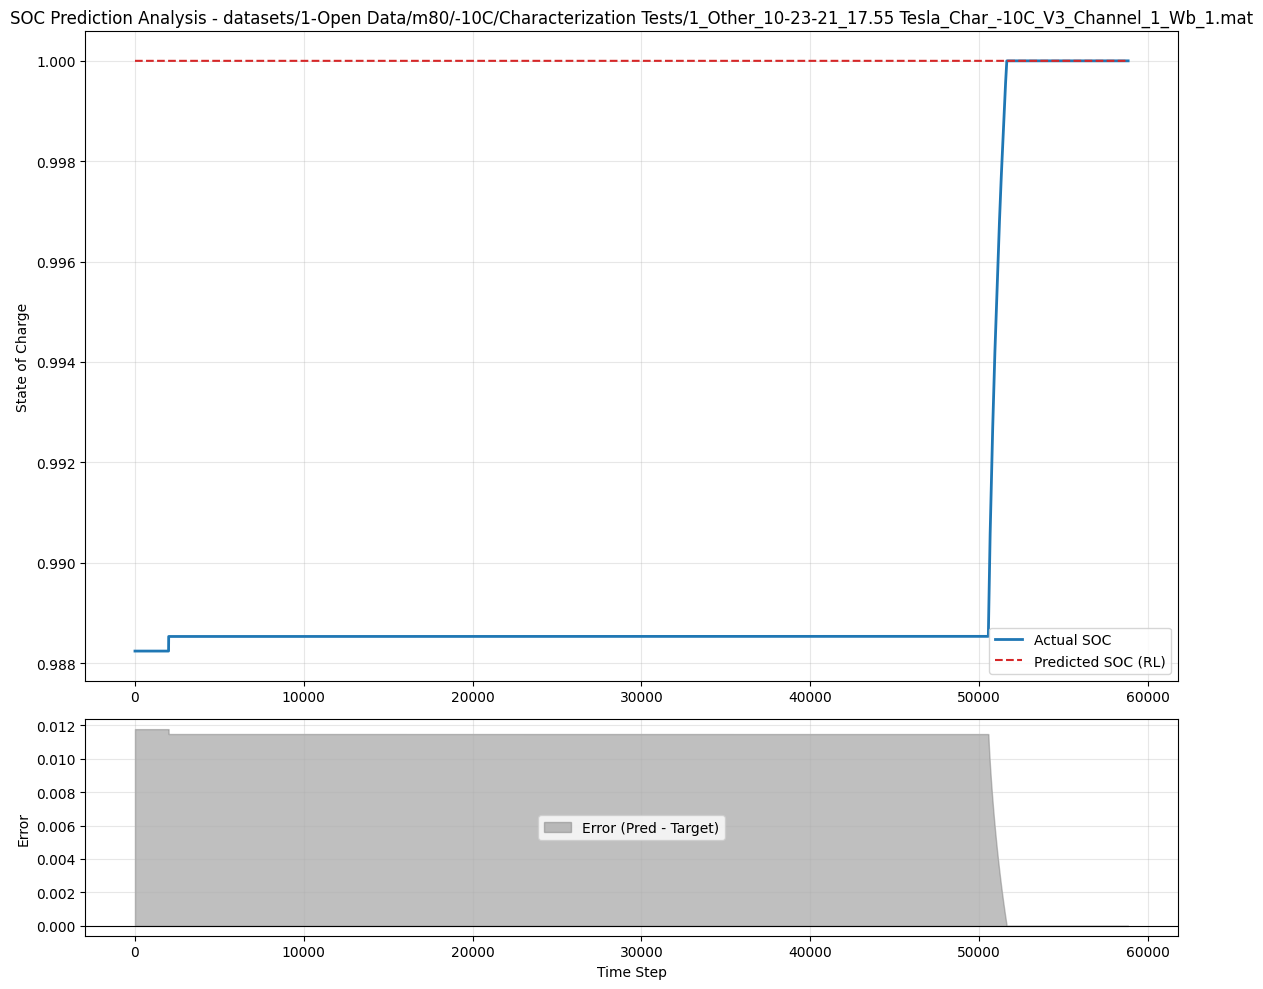

{'mae': np.float64(0.00994944616983214),
 'rmse': np.float64(0.01066814671083054),
 'mape': np.float64(1.0064575080293856),
 'r2': -6.680544817307215}

In [ ]:
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from sklearn.metrics import mean_squared_error, r2_score

features = ['Voltage', 'Current', 'Ah', 'Power', 'Wh']
scaler = MinMaxScaler()


df_master[features] = scaler.fit_transform(df_master[features])

sessions = df_master['Session_ID'].unique()
train_sessions = sessions[:int(0.8 * len(sessions))]
test_sessions = sessions[int(0.8 * len(sessions)):]

df_train = df_master[df_master['Session_ID'].isin(train_sessions)].reset_index(drop=True)
df_test = df_master[df_master['Session_ID'].isin(test_sessions)].reset_index(drop=True)

class BatteryEnv(gym.Env):
    def __init__(self, df):
        super(BatteryEnv, self).__init__()
        self.df = df
        self.sessions = df['Session_ID'].unique()
        
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)
        
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(5,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        session_id = np.random.choice(self.sessions)
        self.episode_data = self.df[self.df['Session_ID'] == session_id].reset_index(drop=True)
        self.current_step = 0
        return self._get_obs(), {}

    def _get_obs(self):
        row = self.episode_data.iloc[self.current_step]
        return np.array(row[features].values, dtype=np.float32)

    def step(self, action):
        target_soc = self.episode_data.iloc[self.current_step]['SOC']
        
        reward = -abs(action[0] - target_soc)
        
        self.current_step += 1
        terminated = self.current_step >= len(self.episode_data) - 1
        
        obs = self._get_obs() if not terminated else np.zeros(self.observation_space.shape, dtype=np.float32)
        
        return obs, reward, terminated, False, {"target": target_soc}

env = BatteryEnv(df_train)

policy_kwargs = dict(net_arch=dict(pi=[128, 128, 64], qf=[128, 128, 64]))
model = PPO("MlpPolicy", env, policy_kwargs=policy_kwargs, verbose=1, learning_rate=0.0003)

print("Memulai Training...")
model.learn(total_timesteps=100000)
model.save("ppo_soc_battery")

def evaluate_model(model, df_eval):
    # Mengambil session pertama dari data evaluasi
    test_session_id = df_eval['Session_ID'].unique()[0]
    data_test = df_eval[df_eval['Session_ID'] == test_session_id].reset_index(drop=True)
    
    predictions = []
    targets = []
    
    # Inisialisasi observasi pertama
    obs = np.array(data_test.iloc[0][features].values, dtype=np.float32)
    
    print(f"--- Mengevaluasi Session: {test_session_id} ---")
    
    for i in range(len(data_test)):
        # Predict menggunakan model RL
        action, _states = model.predict(obs, deterministic=True)
        predictions.append(action[0])
        targets.append(data_test.iloc[i]['SOC'])
        
        # Update observasi ke step berikutnya
        if i + 1 < len(data_test):
            obs = np.array(data_test.iloc[i+1][features].values, dtype=np.float32)

    # Konversi ke numpy array untuk kalkulasi metrik
    targets = np.array(targets)
    predictions = np.array(predictions)

    # --- Kalkulasi Metrik ---
    mae = np.mean(np.abs(targets - predictions))
    rmse = np.sqrt(mean_squared_error(targets, predictions))
    r2 = r2_score(targets, predictions)
    
    # MAPE handling (hindari pembagian dengan nol jika SOC ada yang 0)
    # Kita tambahkan epsilon kecil 1e-10
    mape = np.mean(np.abs((targets - predictions) / (targets + 1e-10))) * 100

    # --- Print Hasil ---
    print(f"MAE   : {mae:.5f}")
    print(f"RMSE  : {rmse:.5f}")
    print(f"MAPE  : {mape:.2f}%")
    print(f"R2    : {r2:.5f}")

    # --- Visualisasi ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

    # Plot Utama SOC
    ax1.plot(targets, label='Actual SOC', color='#1f77b4', linewidth=2)
    ax1.plot(predictions, label='Predicted SOC (RL)', color='#d62728', linestyle='--')
    ax1.set_title(f'SOC Prediction Analysis - {test_session_id}')
    ax1.set_ylabel('State of Charge')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot Error (Residuals)
    error = predictions - targets
    ax2.fill_between(range(len(error)), error, color='gray', alpha=0.5, label='Error (Pred - Target)')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel('Error')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {"mae": mae, "rmse": rmse, "mape": mape, "r2": r2}
evaluate_model(model, df_test)